<div class="alert alert-block alert-danger">
    <b> UNTANGLING THE CYTOSKELETON: A MODEL TO DESCRIBE CYTOSKELETAL ORGANIZATION - CODE</b> 
    
 **3 - CELL SEGMENTATION**
    
**Author**: Diogo Fróis Vieira
</div>

<div class="alert alert-block alert-info">
    
 **IMPORTS**
    
</div>

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from packageCYSK.importing import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
import pickle
import cv2
from packageCYSK.manual_segmentation import *

print('📚 All libraries successfully imported **(for ROI selection)** 📚')

📚 All libraries successfully imported **(for ROI selection)** 📚


<div class="alert alert-block alert-info">
    
 **DIRECTORIES**
    
</div>

In [2]:
folder      = os.getcwd() + "\\data"

# Import images from CYTO, NUCL and RGB folders.
options     = ["CYTO"]

# Dictionary with keys "CYTO", "NUCL", "RGB".
data = init_import(folder,options)

Voxel depth (Z-spacing) could not be determined. Set to 1 (default).
>>> [CYTO] added.


In [3]:
data['CYTO']

,Path,Name,Label,Label 2,Resolution,Image,Image Size
HPA,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,Cells,abc.tif,"(1, 0.08, 0.08)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(2048, 2048)"


<div class="alert alert-block alert-info">
    
 **INSTRUCTIONS**
    
</div>

**1.** Select an image.

**2.** Draw a polygonal ROI around the cell of interest with left clicks. Once done, right click, a new window will open and a new ROI can be drawn. A new entry of ```ROIs``` was added with the mask just drawn.

**3.** Once done, close the window and observe the dataframe with the ROIs. You can delete the last row of ```ROIs``` if you drew an invalid polygon.

**4.** Repeat this process if you have a dataset of images. 

<div class="alert alert-block alert-info">
    
 **SELECT IMAGE**
    
</div>

In [4]:
def dropdown_image_eventhandler(change):
    global idx
    idx = dropdown_image.value
    lab = data['CYTO']['Label'][dropdown_image.value]
    print('Image ' + str(idx) + ' (' + str(lab) +') selected.')

dropdown_image = widgets.Dropdown(description =  'Select Image:' , options = ['...'] + list(data['CYTO'].index))
dropdown_image.observe(dropdown_image_eventhandler, names='value')
display(dropdown_image)

Dropdown(description='Select Image:', options=('...', 'HPA'), value='...')

Image HPA (Cells) selected.


<div class="alert alert-block alert-info">
    
 **ROI SELECTION**
    
</div>

In [5]:
%matplotlib qt
ROIs = roi_selector(data,idx)

🔎
Window closed
list index out of range


In [6]:
ROIs

,Name,Index,Label,Image Size,ROImask
0,Cells_HPA_Cells_abc.tif,HPA,Cells,"(2048, 2048)","([163, 164, 164, 164, 164, 164, 165, 165, 165,..."


**DELETE LAST ROW**

In [25]:
ROIs.drop(ROIs.tail(1).index,inplace=True)

<div class="alert alert-block alert-info">
    
 **PLOT ROIs**
    
</div>

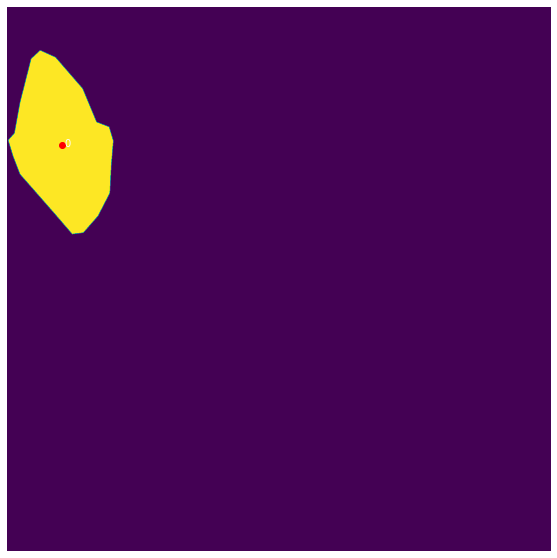

In [7]:
%matplotlib inline
plot_selected_ROIs(ROIs,idx)

<div class="alert alert-block alert-info">
    
 **SAVE ROIs**
    
</div>

In [8]:
ROIs.to_pickle(folder + '\\ROIs_HPA_TEST2.pkl')   

---